In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix
from sklearn.decomposition import PCA

from utils import plot_dendrogram

In [51]:
dataset = pd.read_csv('Pokemon.csv').drop('#', axis = 1)

dataset.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [52]:
dataset.columns

Index(['Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='str')

In [53]:
dataset.isna().sum()

Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [54]:
dataset_num = dataset.select_dtypes(include= 'number')
dataset_cat = dataset.select_dtypes(exclude = 'number')

dataset_num.head()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,318,45,49,49,65,65,45,1
1,405,60,62,63,80,80,60,1
2,525,80,82,83,100,100,80,1
3,625,80,100,123,122,120,80,1
4,309,39,52,43,60,50,65,1


In [55]:
dataset_num.drop(['Total', 'Generation'], axis = 1, inplace=True)

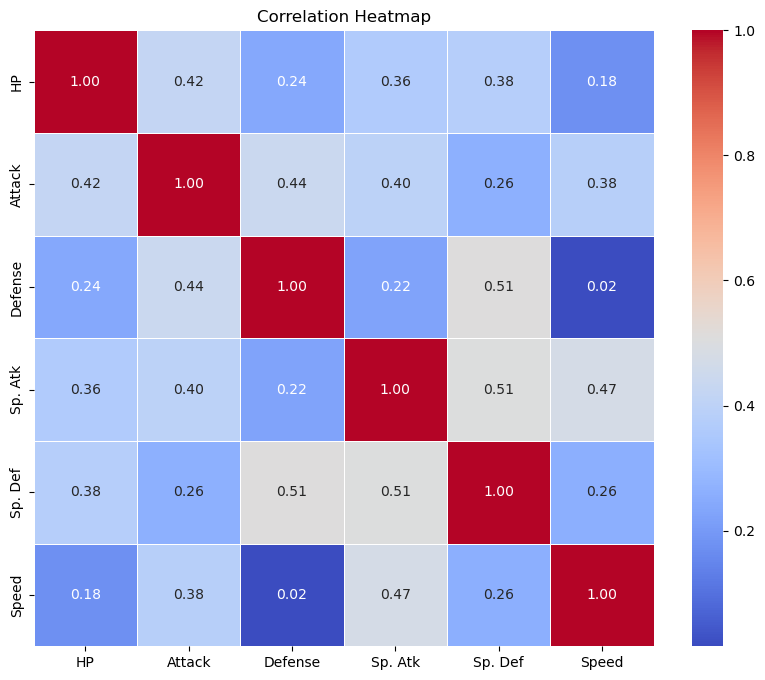

Top 5 feature combinations with highest correlation:
Defense & Sp. Def: 0.511 (abs: 0.511)
Sp. Atk & Sp. Def: 0.506 (abs: 0.506)
Sp. Atk & Speed: 0.473 (abs: 0.473)
Attack & Defense: 0.439 (abs: 0.439)
HP & Attack: 0.422 (abs: 0.422)


In [56]:
#We need to check if we have redundant features in our dataset, so we will check the correlation.
corr = dataset_num.corr()

plt.figure(figsize=(10, 8)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Get the upper triangle of the correlation matrix (excluding self-correlations on the diagonal)
corr_upper = corr.where(np.triu(np.ones_like(corr), k=1).astype(bool))

# Stack the correlations into a Series with multi-index (feature pairs)
corr_pairs = corr_upper.stack()

# Sort by absolute correlation value (highest first) and take top 5
top_5 = corr_pairs.abs().sort_values(ascending=False).head(5)

print("Top 5 feature combinations with highest correlation:")
for (feat1, feat2), abs_corr in top_5.items():
    actual_corr = corr_pairs.loc[(feat1, feat2)]
    print(f"{feat1} & {feat2}: {actual_corr:.3f} (abs: {abs_corr:.3f})")

In [57]:
dataset_num["Physical_bulk"] = np.log1p(dataset["HP"] * dataset["Defense"])
dataset_num["Special_bulk"] = np.log1p(dataset["HP"] * dataset["Sp. Def"])
dataset_num["Best_offense"] = dataset[["Attack", "Sp. Atk"]].max(axis = 1)
dataset_num["Offense_bias"] = dataset["Attack"] - dataset["Sp. Atk"]
dataset_num['Defensive_bias'] = dataset['Defense'] - dataset['Sp. Def']

dataset_num

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Physical_bulk,Special_bulk,Best_offense,Offense_bias,Defensive_bias
0,45,49,49,65,65,45,7.698936,7.981392,65,-16,-16
1,60,62,63,80,80,60,8.237744,8.476580,80,-18,-17
2,80,82,83,100,100,80,8.801018,8.987322,100,-18,-17
3,80,100,123,122,120,80,9.194313,9.169623,122,-22,3
4,39,52,43,60,50,65,7.425358,7.576097,60,-8,-7
...,...,...,...,...,...,...,...,...,...,...,...
795,50,100,150,100,150,50,8.922792,8.922792,100,0,0
796,50,160,110,160,110,110,8.612685,8.612685,160,0,0
797,80,110,60,150,130,70,8.476580,9.249657,150,-40,-70
798,80,160,60,170,130,80,8.476580,9.249657,170,-10,-70


## Clustering using only the original features

In [58]:
dataset_num_original = dataset_num.drop(["Physical_bulk","Special_bulk", "Best_offense", "Offense_bias", "Defensive_bias"], axis = 1)

dataset_num_new = dataset_num.drop(['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def'], axis = 1) #we maintain speed for the dataset with only the "new" features

In [59]:
scaler = StandardScaler()

num_scaled_original = scaler.fit_transform(dataset_num_original) #this returns by itself an array

#we need to put it as a dataframe so that we can merge with the categorical data
#num_scaled_original = pd.DataFrame(num_scaled_original, columns=dataset_num_original.columns, index = dataset.index)

#dataset_scaled_original = pd.concat([dataset_cat, num_scaled_original], axis=1)

In [60]:
pca = PCA(n_components=2) #we want to visualize in a 2D scatterplot

orginal_features_pca = pca.fit_transform(num_scaled_original)

pca_df = pd.DataFrame(
    orginal_features_pca,
    columns=['PC1', 'PC2']
)

pca_df['Name'] = dataset['Name']

First let's apply **KMeans**:

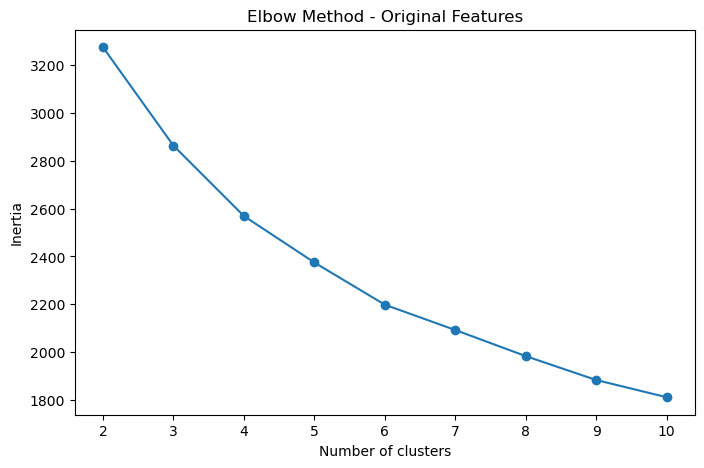

In [61]:
#Here we'll use the elbow method to find a good number of clusters, k.

inertias = []  

K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled_original)
    inertias.append(kmeans.inertia_)  #inertia tells how much information we loose by adding an extra cluster

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Original Features')
plt.show()

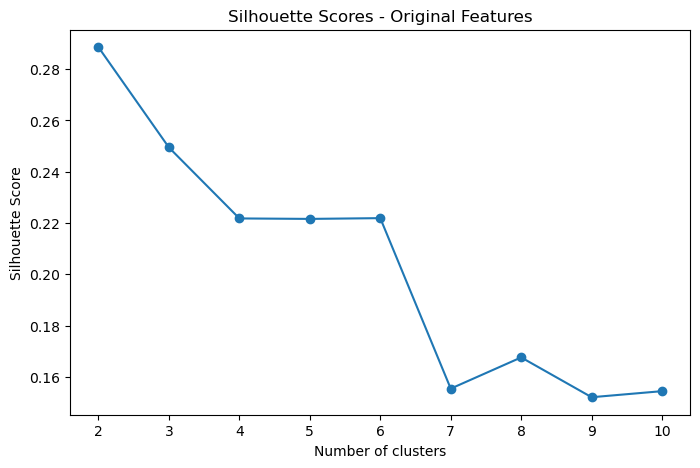

In [62]:
#Now using the silhouette score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled_original)
    labels = kmeans.fit_predict(num_scaled_original)
    silhouette_scores.append(silhouette_score(num_scaled_original, labels))


plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - Original Features')
plt.show()

Let's interpret the clustering with k = 4, and then test with k = 5 and k = 6

**Important Note**: We used k = 6

In [63]:
kmeans = KMeans(n_clusters = 6, random_state = 0).fit(num_scaled_original)
dataset_num_original['cluster_kmeans_original'] = kmeans.predict(num_scaled_original)

In [64]:
dataset_num_original.groupby('cluster_kmeans_original').mean()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
cluster_kmeans_original,,,,,,
0,65.883117,73.740260,66.077922,86.233766,75.051948,95.948052
1,79.701613,110.653226,85.274194,64.564516,70.653226,70.282258
2,50.261484,53.749117,52.084806,48.282686,49.448763,49.194346
3,90.849057,120.962264,94.037736,122.405660,98.688679,98.801887
4,61.358491,84.452830,139.811321,64.301887,96.660377,43.773585
5,103.400000,70.187500,77.575000,86.537500,95.312500,55.200000


The K-Means clustering using only the original features produced four distinct stat profiles. One cluster represented low-stat Pokémon, while another represented high-stat Pokémon with strong offensive and defensive attributes. A separate cluster showed a defensive profile, characterized by very high Defense and low Speed, suggesting a tank-like group. However, the results also indicate that clustering with original features is strongly influenced by overall stat magnitude, since some clusters reflect general strength rather than specific battle roles. This motivates the later use of engineered features to better capture role-based differences such as glass-cannon, tank, or sweeper profiles.

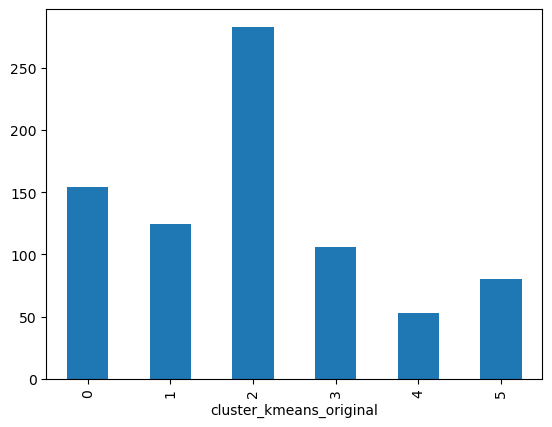

In [65]:
dataset_num_original.groupby(['cluster_kmeans_original']).size().plot(kind='bar')
plt.show()

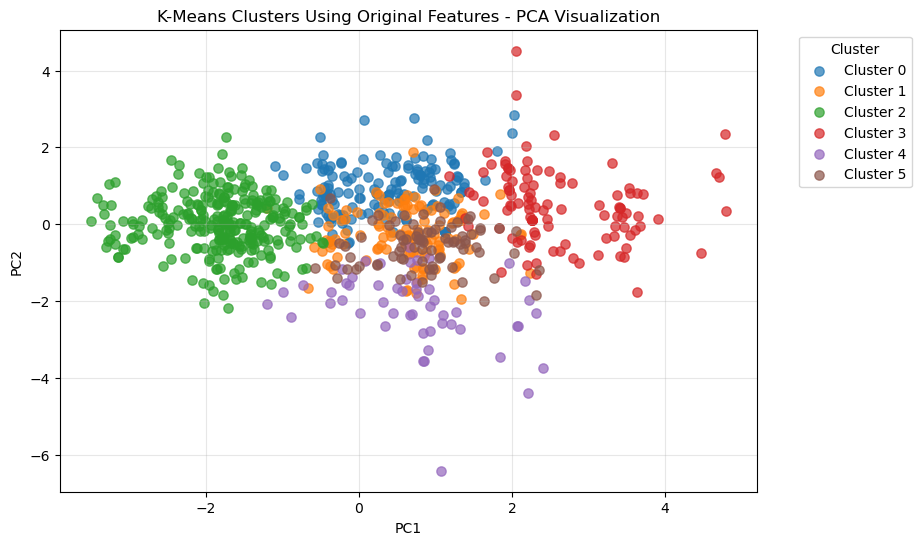

In [66]:
pca_df = pca_df.reset_index(drop=True)
dataset_num_original = dataset_num_original.reset_index(drop=True)

pca_df['cluster_kmeans_original'] = dataset_num_original['cluster_kmeans_original']


plt.figure(figsize=(9, 6))

clusters = sorted(pca_df['cluster_kmeans_original'].unique())

for cluster in clusters:
    cluster_data = pca_df[pca_df['cluster_kmeans_original'] == cluster]
    
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7,
        s=45
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters Using Original Features - PCA Visualization')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

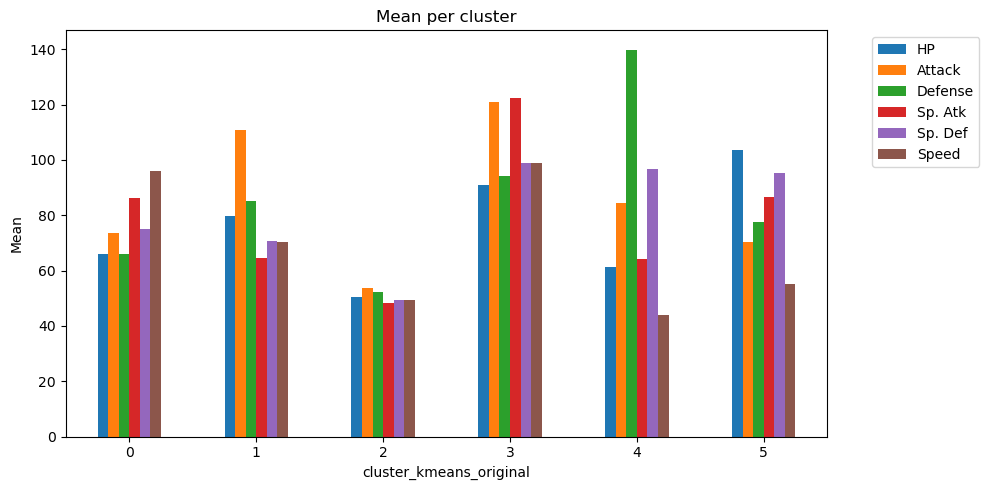

In [67]:
cluster_means = dataset_num_original.groupby('cluster_kmeans_original')[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].mean()

cluster_means.plot(kind='bar', figsize=(10, 5))
plt.title('Mean per cluster')
plt.ylabel('Mean')
plt.xticks(rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [68]:
print(pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

[0.45190665 0.18225358]
Total variance explained: 0.6341602266029069


So based on the clusters we previously did, we can conclude the following Pokemon group types:

- Cluster 0: **Balanced** since we can check moderate stats across the board (65.88 HP, 73.74 Defense, 95.95 Speed). Slightly tilted toward balanced offensive positioning.

- Cluster 1: **Physical Attacker** since we see high Attack (110.65), moderate Speed (70.28), but lower defenses. Good physical glass cannon potential.

- Cluster 2: **Glass Cannon** as they have notably low HP (50.26), low Defense (52.08), low Sp. Def (49.45). Fragile but specialized offensive role.

- Cluster 3: **Special Attacker** as they have very high Sp. Atk (122.41), high HP (90.85), high Speed (98.80), very high Defense (94.04). Balanced offensive special attacker.

- Cluster 4: **Wall/Tank** since we have moderate HP (61.36), extremely high Defense (139.81), very high Sp. Atk (139.81), but low Speed (43.77). Pure defensive focus with special attack wall.

- Cluster 5: **Tank/Defensive** since we can check very high HP (103.40), high Defense/Sp. Def (
approximately 95), moderate offenses (70.19 Attack, 77.58 Sp. Atk), low Speed (55.20). Classic tanky Pokemon.

Using **Hierarchical clustering** on the original features

In [69]:
hierarchical_original = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(num_scaled_original)

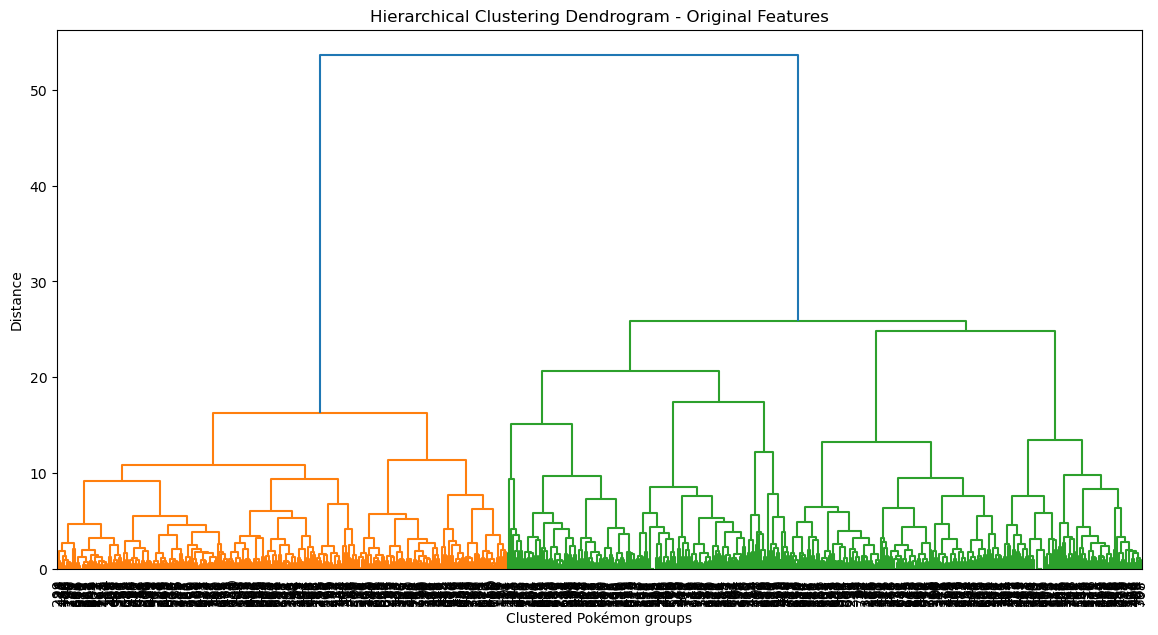

In [70]:
fig, ax = plt.subplots(figsize=(14,7))
plt.title("Hierarchical Clustering Dendrogram - Original Features")
# plot the top three levels of the dendrogram
plot_dendrogram(hierarchical_original, truncate_mode="level", p=20, leaf_rotation=90,leaf_font_size=10)


plt.xlabel("Clustered Pokémon groups")
plt.ylabel("Distance")
plt.show()

In [71]:
dataset_num_original['cluster_ward_original'] = AgglomerativeClustering(
    linkage='ward', n_clusters=6
    ).fit_predict(num_scaled_original)

In [72]:
pd.DataFrame(
    confusion_matrix(
        dataset_num_original['cluster_kmeans_original'],
        dataset_num_original['cluster_ward_original']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 6)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 6)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster
K-Means 0 Cluster,21,1,12,106,0,14
K-Means 1 Cluster,16,51,4,45,0,8
K-Means 2 Cluster,281,0,0,2,0,0
K-Means 3 Cluster,0,0,85,1,0,20
K-Means 4 Cluster,11,2,1,2,31,6
K-Means 5 Cluster,3,41,0,1,1,34


The comparison matrix shows partial agreement between K-Means and Hierarchical Clustering. Both algorithms strongly agree on one large group, corresponding to the low-stat Pokémon cluster. However, several other K-Means clusters are split across multiple hierarchical clusters, indicating that the separation of intermediate stat profiles is less stable. This suggests that, using only the original features, some Pokémon groups are clearly identifiable, while others depend more strongly on the clustering method used.

## Clustering using the engineered features

In [73]:
num_scaled_new = scaler.fit_transform(dataset_num_new)

In [74]:
pca = PCA(n_components=2) #we want to visualize in a 2D scatterplot

new_features_pca = pca.fit_transform(num_scaled_new)

pca_df_new = pd.DataFrame(
    new_features_pca,
    columns=['PC1', 'PC2']
)

pca_df_new['Name'] = dataset['Name']

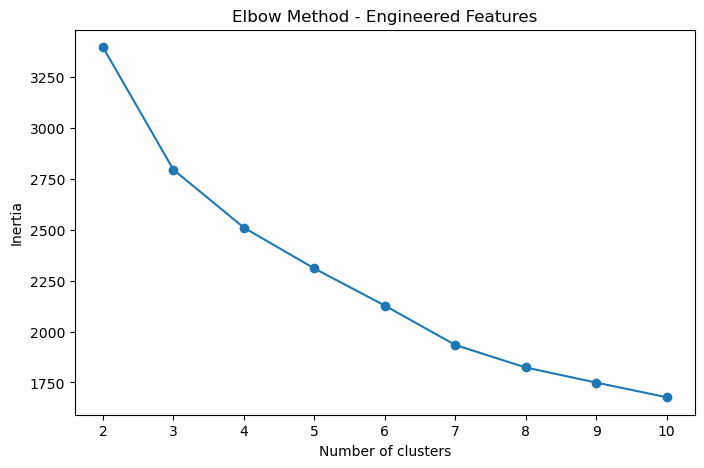

In [75]:
inertias = []  

K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled_new)
    inertias.append(kmeans.inertia_)  #inertia tells how much information we loose by adding an extra cluster

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Engineered Features')
plt.show()

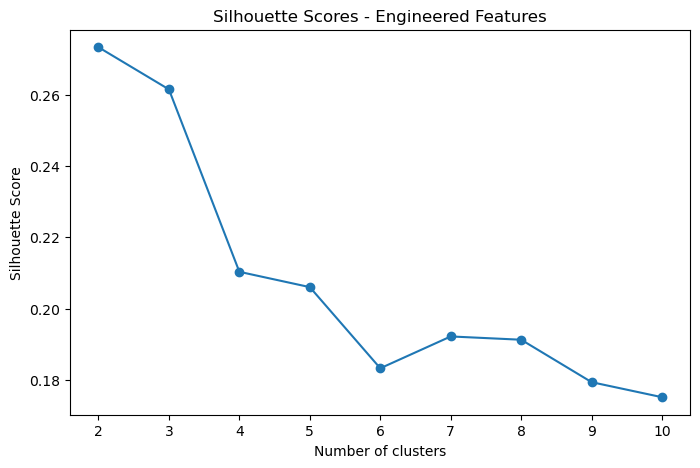

In [76]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled_new)
    labels = kmeans.fit_predict(num_scaled_new)
    silhouette_scores.append(silhouette_score(num_scaled_new, labels))


plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - Engineered Features')
plt.show()

From the silhouette score we chose k = 3. K = 4 and k = 5 are also good candidates. 

In [77]:
kmeans = KMeans(n_clusters= 3, random_state=0).fit(num_scaled_new)
dataset_num_new['cluster_kmeans_engineered'] = kmeans.predict(num_scaled_new)

In [78]:
dataset_num_new.groupby('cluster_kmeans_engineered').mean().round(2)

,Speed,Physical_bulk,Special_bulk,Best_offense,Offense_bias,Defensive_bias
cluster_kmeans_engineered,,,,,,
0,81.88,8.65,8.81,101.53,-17.29,-12.38
1,50.44,7.77,7.72,60.71,6.00,3.56
2,72.81,8.90,8.63,114.54,47.68,24.51


The engineered-feature clustering with k = 3 produced three interpretable groups.
Cluster 0 contains faster and relatively balanced Pokémon with good offensive capability and slightly stronger special bulk.
Cluster 1 groups physically oriented Pokémon with the highest offensive output, strongest physical bulk, and stronger physical than special defense.
Cluster 2 includes slower and less offensively powerful Pokémon, with lower bulk and a more balanced but less specialized profile.
Overall, the engineered features appear to produce clusters that are easier to interpret in terms of Pokémon battle roles.

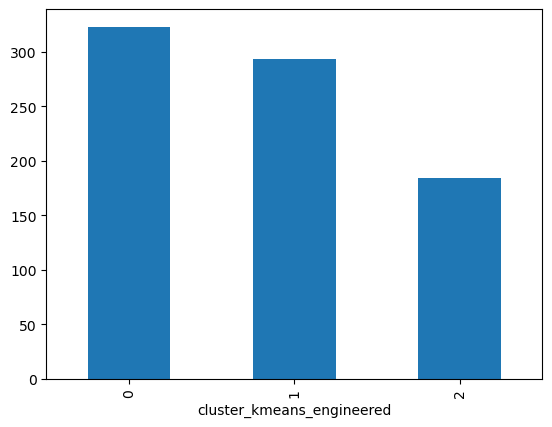

In [79]:
dataset_num_new.groupby(['cluster_kmeans_engineered']).size().plot(kind='bar')
plt.show()

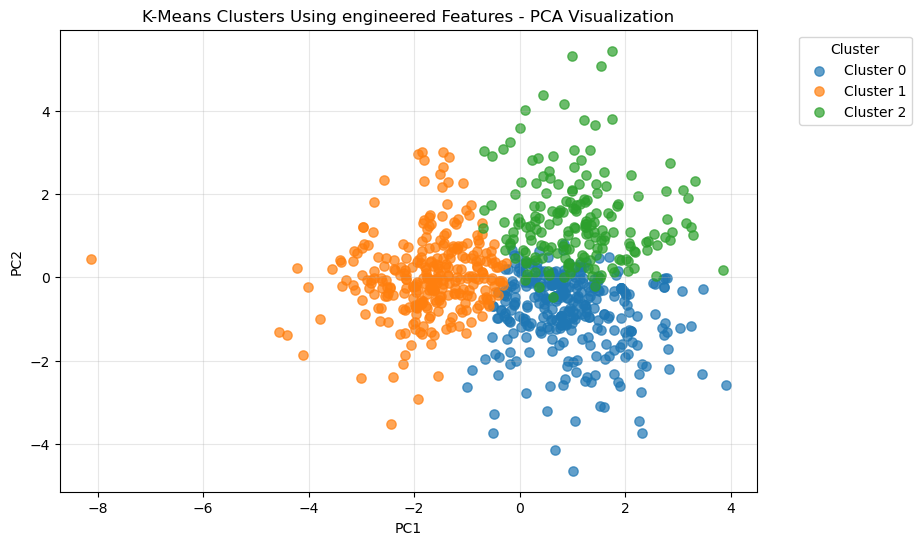

In [80]:
pca_df_new = pca_df_new.reset_index(drop=True)
dataset_num_new = dataset_num_new.reset_index(drop=True)

pca_df_new['cluster_kmeans_engineered'] = dataset_num_new['cluster_kmeans_engineered']


plt.figure(figsize=(9, 6))

clusters = sorted(pca_df_new['cluster_kmeans_engineered'].unique())

for cluster in clusters:
    cluster_data = pca_df_new[pca_df_new['cluster_kmeans_engineered'] == cluster]
    
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7,
        s=45
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters Using engineered Features - PCA Visualization')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

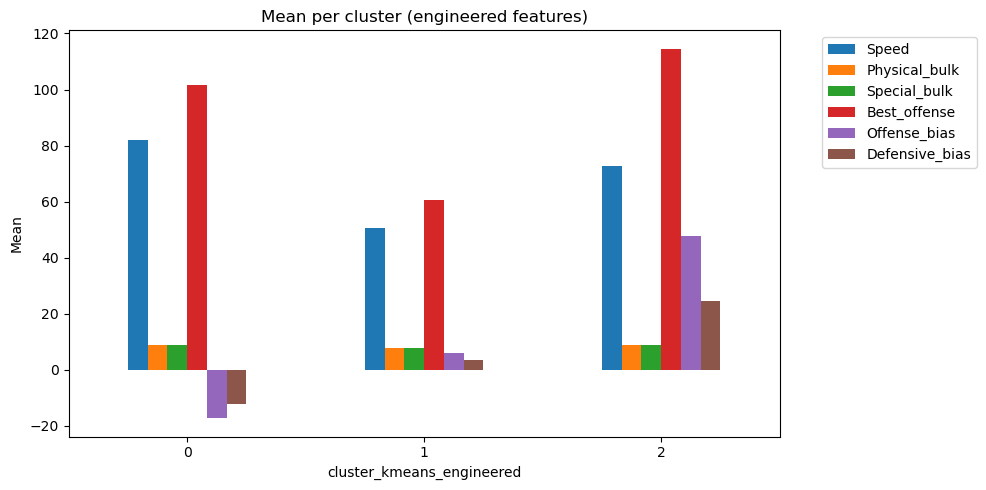

In [81]:
cluster_means_engineered = dataset_num_new.groupby('cluster_kmeans_engineered')[
    ['Speed', 'Physical_bulk', 'Special_bulk', 'Best_offense', 'Offense_bias', 'Defensive_bias']
].mean()

cluster_means_engineered.plot(kind='bar', figsize=(10, 5))
plt.title('Mean per cluster (engineered features)')
plt.ylabel('Mean')
plt.xticks(rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [82]:
print(pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

[0.41725561 0.27073667]
Total variance explained: 0.6879922754344947


Looking at each cluster characteristics, we conclude the following:

- Cluster 0: **Speed-based Special Attacker** since we observe high Speed (81.88), strong best_offense (101.53), negative offense_bias (-17.29) indicates special attack focus, negative defensive_bias (-12.38) shows special defense preference. Fast special sweeper archetype.

- Cluster 1: **Glass Cannon** as they have very low Speed (50.44), low bulk stats (7.77 physical, 7.72 special), low best_offense (60.71). Extremely fragile Pokemon with minimal defensive presence. Slow and frail.

- Cluster 2: **Physical Attacker / Balanced Tank** as we can check mmoderate Speed (72.81), highest bulk stats (8.90 physical, 8.63 special), very high best_offense (114.54), strong positive offense_bias (47.68) indicates physical attack dominance, defensive_bias (24.51) shows physical defense focus. Well-rounded physical attacker with good durability.

Now moving on to **Hierarchical Clustering**:

In [83]:
hierarchical_engineered = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(num_scaled_new)

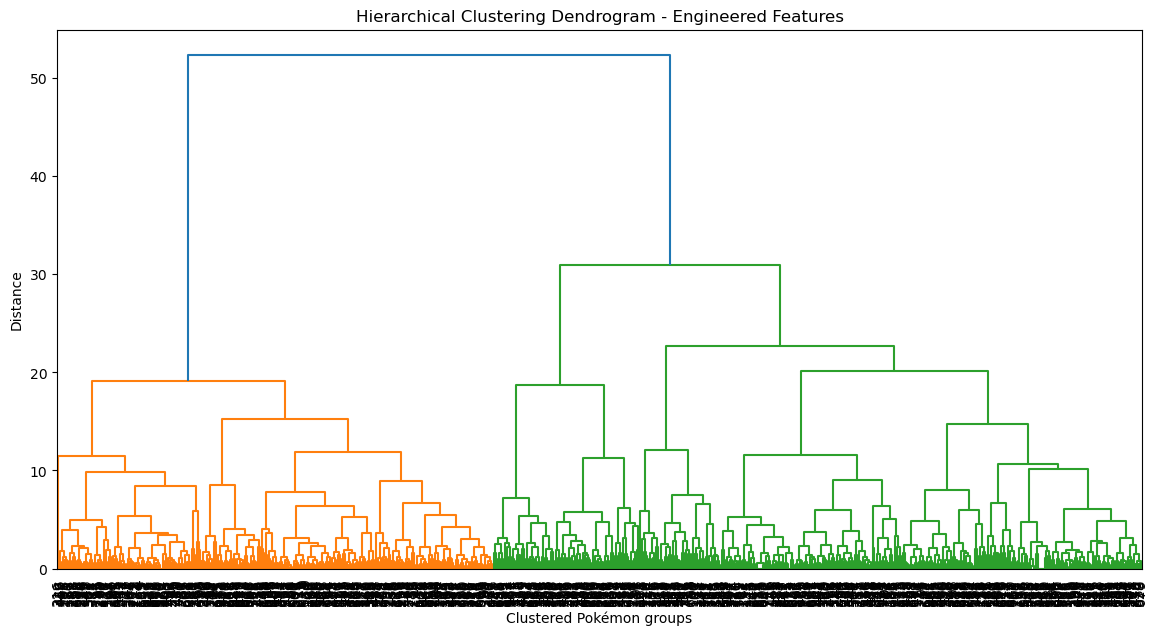

In [84]:
fig, ax = plt.subplots(figsize=(14,7))
plt.title("Hierarchical Clustering Dendrogram - Engineered Features")
# plot the top three levels of the dendrogram
plot_dendrogram(hierarchical_engineered, truncate_mode="level", p=20, leaf_rotation=90,leaf_font_size=10)


plt.xlabel("Clustered Pokémon groups")
plt.ylabel("Distance")
plt.show()

In [85]:
dataset_num_new['cluster_ward_engineered'] = AgglomerativeClustering(
    linkage='ward', n_clusters=3
    ).fit_predict(num_scaled_new)

In [86]:
pd.DataFrame(
    confusion_matrix(
        dataset_num_new['cluster_kmeans_engineered'],
        dataset_num_new['cluster_ward_engineered']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 3)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 3)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster
K-Means 0 Cluster,288,32,3
K-Means 1 Cluster,6,286,1
K-Means 2 Cluster,77,4,103


In [ ]:
# Define cluster type mappings based on your interpretations
# For original features KMeans (6 clusters)
kmeans_original_types = {
    0: "Balanced (moderate stats, slightly offensive)",
    1: "Physical Attacker (high Attack, moderate Speed, low defenses)",
    2: "Glass Cannon (low HP/Defense/Sp.Def, fragile offensive)",
    3: "Special Attacker (high Sp.Atk, HP, Speed, Defense)",
    4: "Wall/Tank (high Defense/Sp.Def, low Speed, defensive focus)",
    5: "Tank/Defensive (high HP/Defenses, moderate offenses, low Speed)"
}

# For original features Hierarchical (6 clusters, assuming similar interpretation; adjust if needed)
ward_original_types = kmeans_original_types  # Using same for simplicity; you can customize

# For engineered features KMeans (3 clusters)
kmeans_engineered_types = {
    0: "Speed-based Special Attacker (high Speed, special focus)",
    1: "Glass Cannon (low Speed/bulk, frail)",
    2: "Physical Attacker / Balanced Tank (high physical bulk/offense)"
}

# For engineered features Hierarchical (3 clusters, assuming similar)
ward_engineered_types = kmeans_engineered_types  # Using same for simplicity

# Interactive function
def get_pokemon_cluster_type():
    # Ask for Pokémon name
    name = input("Enter Pokémon name: ").strip()
    
    # Find the Pokémon in the dataset
    pokemon_row = dataset[dataset['Name'].str.lower() == name.lower()]
    if pokemon_row.empty:
        print("Pokémon not found.")
        return
    
    # Get index to match with num datasets
    idx = pokemon_row.index[0]
    
    # Ask for clustering technique
    technique = input("Choose clustering technique (kmeans or hierarchical): ").strip().lower()
    
    # Ask for features (original or engineered)
    features = input("Choose features (original or engineered): ").strip().lower()
    
    if technique == "kmeans":
        if features == "original":
            cluster = dataset_num_original.loc[idx, 'cluster_kmeans_original']
            cluster_type = kmeans_original_types.get(cluster, "Unknown")
        elif features == "engineered":
            cluster = dataset_num_new.loc[idx, 'cluster_kmeans_engineered']
            cluster_type = kmeans_engineered_types.get(cluster, "Unknown")
        else:
            print("Invalid features choice.")
            return
    elif technique == "hierarchical":
        if features == "original":
            cluster = dataset_num_original.loc[idx, 'cluster_ward_original']
            cluster_type = ward_original_types.get(cluster, "Unknown")
        elif features == "engineered":
            cluster = dataset_num_new.loc[idx, 'cluster_ward_engineered']
            cluster_type = ward_engineered_types.get(cluster, "Unknown")
        else:
            print("Invalid features choice.")
            return
    else:
        print("Invalid technique choice.")
        return
    
    print(f"{name} belongs to cluster {cluster}: {cluster_type}")

# Run the function
get_pokemon_cluster_type()